In [4]:
!pip uninstall tensorflow -y
!pip uninstall keras -y

Found existing installation: tensorflow 2.19.0
Uninstalling tensorflow-2.19.0:
  Successfully uninstalled tensorflow-2.19.0
Found existing installation: keras 3.9.1
Uninstalling keras-3.9.1:
  Successfully uninstalled keras-3.9.1


In [5]:
!pip install --upgrade pip

Defaulting to user installation because normal site-packages is not writeable

ERROR: To modify pip, please run the following command:
C:\ProgramData\anaconda3\python.exe -m pip install --upgrade pip



  Using cached pip-26.0.1-py3-none-any.whl.metadata (4.7 kB)
Using cached pip-26.0.1-py3-none-any.whl (1.8 MB)


In [6]:
!pip install tensorflow==2.15

  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.


Defaulting to user installation because normal site-packages is not writeable
   ---------------------------------------- 0.0/300.9 MB ? eta -:--:--
   ---------------------------------------- 0.0/300.9 MB ? eta -:--:--
   ---------------------------------------- 0.1/300.9 MB 871.5 kB/s eta 0:05:46
   ---------------------------------------- 0.3/300.9 MB 1.8 MB/s eta 0:02:52
   ---------------------------------------- 0.4/300.9 MB 1.9 MB/s eta 0:02:42
   ---------------------------------------- 0.5/300.9 MB 2.2 MB/s eta 0:02:14
   ---------------------------------------- 0.7/300.9 MB 2.6 MB/s eta 0:01:57
   ---------------------------------------- 0.8/300.9 MB 2.6 MB/s eta 0:01:57
   ---------------------------------------- 0.8/300.9 MB 2.4 MB/s eta 0:02:03
   ---------------------------------------- 1.1/300.9 MB 2.7 MB/s eta 0:01:52
   ---------------------------------------- 1.3/300.9 MB 2.8 MB/s eta 0:01:48
   ---------------------------------------- 1.5/300.9 MB 2.9 MB/s eta 0:01:4

In [7]:
!pip install scikit-learn 

Defaulting to user installation because normal site-packages is not writeable


In [1]:
import numpy as np
import pandas as pd

from sklearn.preprocessing import MinMaxScaler

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense

In [2]:
df = pd.read_csv("data/processed/bitcoin_processed.csv")

data = df["close"].values.reshape(-1,1)

In [3]:
scaler = MinMaxScaler()

data_scaled = scaler.fit_transform(data)

In [4]:
X = []
y = []

for i in range(60, len(data_scaled)):
    
    X.append(data_scaled[i-60:i])
    
    y.append(data_scaled[i])

X = np.array(X)
y = np.array(y)

In [5]:
split = int(len(X)*0.8)

X_train = X[:split]
X_test = X[split:]

y_train = y[:split]
y_test = y[split:]

In [6]:
model = Sequential()

model.add(LSTM(50, return_sequences=True, input_shape=(X_train.shape[1],1)))

model.add(LSTM(50))

model.add(Dense(1))

model.compile(optimizer="adam", loss="mse")

c:\Users\racha\anaconda3\anaconda\Lib\site-packages\keras\src\layers\rnn\rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [7]:
model.fit(X_train, y_train, epochs=10, batch_size=32)

Epoch 1/10
17/17 ━━━━━━━━━━━━━━━━━━━━ 4s 35ms/step - loss: 0.1391
Epoch 2/10
17/17 ━━━━━━━━━━━━━━━━━━━━ 1s 33ms/step - loss: 0.0082
Epoch 3/10
17/17 ━━━━━━━━━━━━━━━━━━━━ 1s 36ms/step - loss: 0.0046
Epoch 4/10
17/17 ━━━━━━━━━━━━━━━━━━━━ 1s 36ms/step - loss: 0.0028
Epoch 5/10
17/17 ━━━━━━━━━━━━━━━━━━━━ 1s 35ms/step - loss: 0.0027
Epoch 6/10
17/17 ━━━━━━━━━━━━━━━━━━━━ 1s 35ms/step - loss: 0.0030
Epoch 7/10
17/17 ━━━━━━━━━━━━━━━━━━━━ 1s 33ms/step - loss: 0.0024
Epoch 8/10
17/17 ━━━━━━━━━━━━━━━━━━━━ 1s 35ms/step - loss: 0.0030
Epoch 9/10
17/17 ━━━━━━━━━━━━━━━━━━━━ 1s 33ms/step - loss: 0.0026
Epoch 10/10
17/17 ━━━━━━━━━━━━━━━━━━━━ 1s 35ms/step - loss: 0.0030


In [8]:
predictions = model.predict(X_test)

predictions = scaler.inverse_transform(predictions)

5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 68ms/step


In [9]:
import os

lstm_pred = pd.DataFrame(predictions, columns=["prediction"])

os.makedirs("../results", exist_ok=True)

lstm_pred.to_csv("../results/lstm_predictions.csv", index=False)

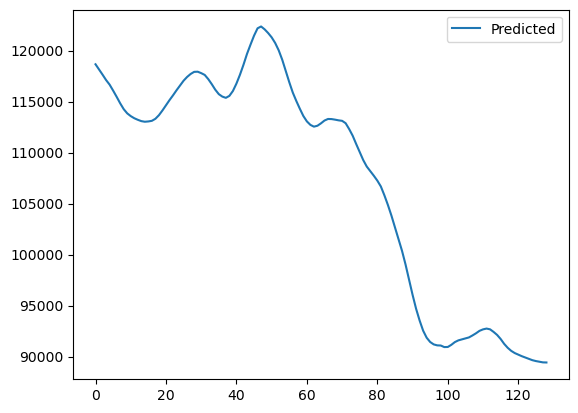

In [10]:
import matplotlib.pyplot as plt

plt.plot(predictions, label="Predicted")

plt.legend()

plt.show()

In [11]:
print(len(predictions))
print(len(lstm_pred["prediction"]))

129
129
